# Four Qubit Chip Design

In [1]:
%reload_ext autoreload
%autoreload 2

## Prerequisite

In [ ]:
import numpy as np
from collections import OrderedDict

from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled

## Create the Four Qbit Design

In [ ]:
design = designs.DesignPlanar()

gui = MetalGUI(design)

In [ ]:
design.overwrite_enabled = True

In [ ]:
design.variables['cpw_width'] = '10 um'
design.variables['cpw_gap'] = '6 um'
design._chips['main']['size']['size_y'] = '9mm'
design._chips['main']['size']['size_y'] = '6.5mm'

We need 4 transmons with 3 connection pads each and a chargeline. Let's explore the options of one transmon

In [ ]:
TransmonPocketCL.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'make_CL': True,
 'cl_gap': '6um',
 'cl_width': '10um',
 'cl_length': '20um',
 'cl_ground_gap': '6um',
 'cl_pocket_edge': '0',
 'cl_off_center': '50um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 

We want to change the `pad_width` for these transmons, as well as define the 3 connection pads and chargeline.

To apply the same modifications to all 4 transmons, we define a single option-dictionary to pass to all transmons at the monent of creation

In [ ]:
transmon_options = dict(
    connection_pads=dict(
        a = dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend = '50um'), 
        b = dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend = '50um'),
        c = dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend = '50um')
    ),
    gds_cell_name='FakeJunction_01',
    cl_off_center = '-50um',
    cl_pocket_edge = '180',
    pad_gap = '30um', # 30 um, 50 um, 80 um, 110 um
    inductor_width = '20um' # 20 um, 10 um, 15 um, 20 um
)

We can now create the 4 transmons by specifying the desired coordinates and orientations.

In [ ]:
offset_tm = 69  #we the transmon slightly out of center-line

# q1 = TransmonPocketCL(design, 'Q1', options = dict(
#      pos_x='+2420um', pos_y=f'428.5um', **transmon_options))
#     # pos_x='+2420um', pos_y=f'{offset_tm}um', **transmon_options))
# q2 = TransmonPocketCL(design, 'Q2', options = dict(
#     pos_x='428.5um', pos_y='-857.6um', orientation = '270', **transmon_options))
# q3 = TransmonPocketCL(design, 'Q3', options = dict(
#     pos_x='-2420um', pos_y=f'-428.5um', orientation = '180', **transmon_options))
#     # pos_x='-2420um', pos_y=f'{offset_tm}um', orientation = '180', **transmon_options))
# q4 = TransmonPocketCL(design, 'Q4', options = dict(
#     pos_x='-428.5um', pos_y='+857.6um', orientation = '90', **transmon_options))

q1 = TransmonPocketCL(design, 'Q1', options = dict(
    pos_x='+2420um', pos_y=f'{offset_tm}um', **transmon_options))
q2 = TransmonPocketCL(design, 'Q2', options = dict(
    pos_x='0um', pos_y='-857.6um', orientation = '270', **transmon_options))
q3 = TransmonPocketCL(design, 'Q3', options = dict(
    pos_x='-2420um', pos_y=f'{offset_tm}um', orientation = '180', **transmon_options))
q4 = TransmonPocketCL(design, 'Q4', options = dict(
    pos_x='0um', pos_y='+857.6um', orientation = '90', **transmon_options))

gui.rebuild()
gui.autoscale()

Let's now connect the transmons with tranismission lines. We want to have an "exact length" transmission line, so we will use the `RouteMeander`. Let's first observe what are the default options

In [ ]:
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

We want to globally override the default lead (straight initial segment leaving the transmon) and the default fillet (corner rounding radius). Let's collect this information in one dictionary

In [ ]:
fillet='99.99um'
cpw_options = Dict(
    lead=Dict(
        start_straight='100um',
        # end_straight='150um'),
        end_straight='250um'),
    fillet=fillet
    )

We then want each transmission line to be connected to different pins and to have different lengths and asymmetry w.r.t their centerline. Let's collect this information in other dictionaries. Before doing that, to manage the dictionaries in a simpler way, we redefine the `RouteMeander` signature by wrapping it into a convenience method named `connect`

In [ ]:
def connect(cpw_name: str, pin1_comp_name: str, pin1_comp_pin: str, pin2_comp_name: str, pin2_comp_pin: str,
            length: str, asymmetry='0 um'):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component=pin1_comp_name,
                pin=pin1_comp_pin),
            end_pin=Dict(
                component=pin2_comp_name,
                pin=pin2_comp_pin)),
        total_length=length)
    myoptions.update(cpw_options)
    myoptions.meander.asymmetry = asymmetry
    return RouteMeander(design, cpw_name, myoptions)

We can now proceed and define the meanders following the signature: `connect(cpw_name, pin1_comp_name, pin1_comp_pin, pin2_comp_name, pin2_comp_pin, length, asymmetry)`

In [ ]:
asym = 500
cpw1 = connect('cpw1', 'Q1', 'c', 'Q4', 'b', '9000um', f'-{asym-1.25*offset_tm}um')
cpw2 = connect('cpw2', 'Q3', 'b', 'Q4', 'c', '9000um', f'+{asym-1.25*offset_tm}um')
cpw3 = connect('cpw3', 'Q3', 'c', 'Q2', 'b', '9000um', f'-{asym+0.75*offset_tm}um')
cpw4 = connect('cpw4', 'Q1', 'b', 'Q2', 'c', '9000um', f'+{asym+0.75*offset_tm}um')

gui.rebuild()
gui.autoscale()

### Let's now connect the core elements to the launchpads

First we setup the launchpad location and orientation

In [ ]:
# V1 - Corners
p1_c = LaunchpadWirebond(design, 'P1_C', options = dict(pos_x='3545um', pos_y='2812um', orientation='270', lead_length='0um'))
p2_c = LaunchpadWirebond(design, 'P2_C', options = dict(pos_x='3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
p3_c = LaunchpadWirebond(design, 'P3_C', options = dict(pos_x='-3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
p4_c = LaunchpadWirebond(design, 'P4_C', options = dict(pos_x='-3545um', pos_y='2812um', orientation='270', lead_length='0um'))

# V2
p1_q = LaunchpadWirebondCoupled(design, 'P1_Q', options = dict(pos_x='4020um', pos_y='0', orientation='180', lead_length='30um'))
p2_q = LaunchpadWirebondCoupled(design, 'P2_Q', options = dict(pos_x='-990um', pos_y='-2812um', orientation='90', lead_length='30um'))
p3_q = LaunchpadWirebondCoupled(design, 'P3_Q', options = dict(pos_x='-4020um', pos_y='0', orientation='0', lead_length='30um'))
p4_q = LaunchpadWirebondCoupled(design, 'P4_Q', options = dict(pos_x='990um', pos_y='2812um', orientation='270', lead_length='30um'))

gui.rebuild()
gui.autoscale()

Then we route. First the V2 launchpads - Exchange Coupler Lines to Edges

Connected to the readout resonators of each qubit

Used for dispersive readout — you send a probe tone and measure the reflected/transmitted signal to determine the qubit state without directly measuring it

In [ ]:
asym = 150
cpw_options = Dict(
    lead=Dict(
        start_straight='430um',
        end_straight='0um'),
    fillet=fillet
    )
ol1 = connect('ol1', 'Q1', 'a', 'P1_Q', 'tie', '8.6 mm', f'+{asym}um')
ol3 = connect('ol3', 'Q3', 'a', 'P3_Q', 'tie', '8.6 mm', f'+{asym}um')

asym = 200
cpw_options = Dict(
    lead=Dict(
        start_straight='535um',
        end_straight='0um'),
    fillet=fillet
    )
ol2 = connect('ol2', 'Q2', 'a', 'P2_Q', 'tie', '8.6 mm', f'+{asym}um')
# ol2 = connect('ol2', 'Q2', 'a', 'P2_Q', 'tie', '5 mm', f'+{asym}um')
ol4 = connect('ol4', 'Q4', 'a', 'P4_Q', 'tie', '8.6 mm', f'+{asym}um')

gui.rebuild()
gui.autoscale()

Finally we route the V1 launchpads - Charge Lines to Corners

We create the transmission lines between the corner launchpads and the open to grounds

Connected to the charge lines of each qubit

Used for single-qubit control — sending microwave pulses to drive qubit transitions

In [ ]:
from collections import OrderedDict
jogsA_in = OrderedDict()
jogsA_in[0] = ["L", '200um']

options_line_cl1 = {'pin_inputs': 
            {'start_pin': {'component': 'Q1', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P1_C', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um','start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
cl1 = RouteAnchors(design, 'line_cl1', options_line_cl1)

options_line_cl3 = {'pin_inputs': 
            {'start_pin': {'component': 'Q3', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P3_C', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um', 'start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
cl3 = RouteAnchors(design, 'line_cl3', options_line_cl3)

gui.rebuild()
gui.autoscale()

In [ ]:
jogsB_in = OrderedDict()
jogsB_in[0] = ["L", '300um']

anchors2c = OrderedDict()
anchors2c[0] = np.array([2, -2.5])

options_line_cl2 = {'pin_inputs': 
            {'start_pin': {'component': 'Q2', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P2_C', 'pin': 'tie'}},
            'lead': {'start_straight': '200um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors2c,
            'fillet': fillet
            }

cl2 = RouteAnchors(design, 'line_cl2', options_line_cl2)

anchors4c = OrderedDict()
anchors4c[0] = np.array([-2, 2.5])

options_line_cl4 = {'pin_inputs': 
            {'start_pin': {'component': 'Q4', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P4_C', 'pin': 'tie'}},
            'lead': {'start_straight': '200um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors4c,
            'fillet': fillet
            }

cl4 = RouteAnchors(design, 'line_cl4', options_line_cl4)

gui.rebuild()
gui.autoscale()

In [ ]:
gui.rebuild()  # rebuild the design and plot 
gui.autoscale() #resize GUI to see QComponent

In [ ]:
# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()

gui.zoom_on_components(all_component_names)

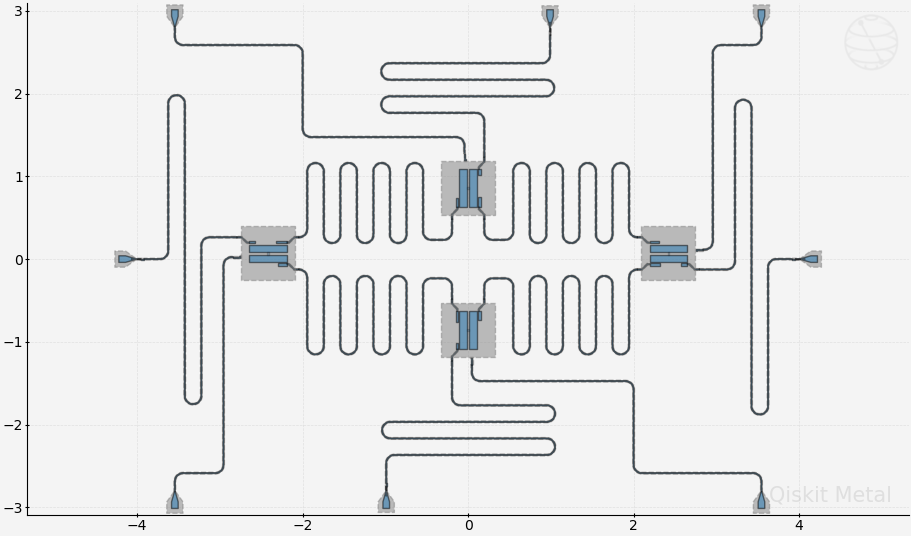

In [ ]:
# Screenshot the canvas only as a .png formatted file.
# gui.screenshot()
gui.figure.savefig('shot.png')

from IPython.display import Image, display
_disp_ops = dict(width=500)
display(Image('shot.png', **_disp_ops))

In [20]:
# # Closing the Qiskit Metal GUI
# gui.main_window.close()

## Analyze the chip using the Eigenmode method and EPR analysis

### Eigenmode

In [21]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (2.42000 0.05400, 2.42000 0.08400)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
1,2,rect_jj,"LINESTRING (-0.01500 -0.85760, 0.01500 -0.85760)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
2,3,rect_jj,"LINESTRING (-2.42000 0.08400, -2.42000 0.05400)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
3,4,rect_jj,"LINESTRING (0.01500 0.85760, -0.01500 0.85760)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0


In [ ]:
qcomps = design.components

qcomps['Q1'].options['hfss_inductance'] = 'Lj1'
qcomps['Q1'].options['hfss_capacitance'] = 'Cj1'
qcomps['Q2'].options['hfss_inductance'] = 'Lj2'
qcomps['Q2'].options['hfss_capacitance'] = 'Cj2'
qcomps['Q3'].options['hfss_inductance'] = 'Lj3'
qcomps['Q3'].options['hfss_capacitance'] = 'Cj3'
qcomps['Q4'].options['hfss_inductance'] = 'Lj4'
qcomps['Q4'].options['hfss_capacitance'] = 'Cj4'

gui.rebuild() # line needed to propagate the updates from the qubit instance into the junction design table
gui.autoscale()

In [26]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_4qb = EPRanalysis(design, "hfss")

In [29]:
eig_4qb.sim.setup.max_passes = 15
eig_4qb.sim.setup.max_delta_f = 0.01
eig_4qb.sim.setup.n_modes = 20 # 16 are the modes of our system, plus 4 gives us buffer for 
eig_4qb.sim.setup.convergence_accuracy="high"
eig_4qb.sim.setup.vars = Dict(Lj1= '13 nH', Cj1= '0 fF', # Cji zero since junction capacitance is captured geometrically by the simulation
                           Lj2= '9 nH', Cj2= '0 fF',
                           Lj3= '13 nH', Cj3= '0 fF',
                           Lj4= '9 nH', Cj4= '0 fF')
eig_4qb.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1,
 'n_modes': 20,
 'max_delta_f': 0.01,
 'max_passes': 15,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj1': '13 nH',
  'Cj1': '0 fF',
  'Lj2': '9 nH',
  'Cj2': '0 fF',
  'Lj3': '13 nH',
  'Cj3': '0 fF',
  'Lj4': '9 nH',
  'Cj4': '0 fF'},
 'convergence_accuracy': 'high'}

|←— 0.5mm —→|←——— chip (9mm) ———→|←— 0.5mm —→|
             ________________________
            |  Q3 ——cpw—— Q4       |
 boundary → |  |              |    | ← boundary
            |  Q2 ——cpw—— Q1       |
            |________________________|


In [ ]:
eig_4qb.sim.renderer.options['x_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm, default was 0.5
eig_4qb.sim.renderer.options['y_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm
eig_4qb.sim.renderer.options

{'Lj': '10nH',
 'Cj': 0,
 '_Rj': 0,
 'max_mesh_length_jj': '7um',
 'max_mesh_length_port': '7um',
 'project_path': None,
 'project_name': None,
 'design_name': None,
 'x_buffer_width_mm': 0.5,
 'y_buffer_width_mm': 0.5,
 'wb_threshold': '400um',
 'wb_offset': '0um',
 'wb_size': 5,
 'plot_ansys_fields_options': {'name': 'NAME:Mag_E1',
  'UserSpecifyName': '0',
  'UserSpecifyFolder': '0',
  'QuantityName': 'Mag_E',
  'PlotFolder': 'E Field',
  'StreamlinePlot': 'False',
  'AdjacentSidePlot': 'False',
  'FullModelPlot': 'False',
  'IntrinsicVar': "Phase='0deg'",
  'PlotGeomInfo_0': '1',
  'PlotGeomInfo_1': 'Surface',
  'PlotGeomInfo_2': 'FacesList',
  'PlotGeomInfo_3': '1'}}

In [31]:
# eig_4qb.sim.run(name="fourTransmons", components=['Q1', 'Q2', 'Q3', 'Q4'])
# eig_4qb.sim.run(name="fourTransmons", components=[])  # empty = all components

eig_4qb.sim.run(name="fourTransmons", components=[
    'Q1', 'Q2', 'Q3', 'Q4',
    'cpw1', 'cpw2', 'cpw3', 'cpw4',      # coupling buses
    'ol1', 'ol2', 'ol3', 'ol4',            # output lines
    'line_cl1', 'line_cl2', 'line_cl3', 'line_cl4',  # charge lines
    'P1_C', 'P2_C', 'P3_C', 'P4_C',       # corner launchpads
    'P1_Q', 'P2_Q', 'P3_Q', 'P4_Q'        # edge launchpads
])


INFO 08:02PM [connect_project]: Connecting to Ansys Desktop API...
INFO 08:02PM [load_ansys_project]: 	Opened Ansys App
INFO 08:02PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 08:02PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project25
INFO 08:02PM [connect_design]: No active design found (or error getting active design).
INFO 08:02PM [connect]: 	 Connected to project "Project25". No design detected
INFO 08:02PM [connect_design]: 	Opened active design
	Design:    fourTransmons_hfss [Solution type: Eigenmode]
WARNING 08:02PM [connect_setup]: 	No design setup detected.
WARNING 08:02PM [connect_setup]: 	Creating eigenmode default setup.
INFO 08:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 08:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 08:02PM [analyze]: Analyzing setup Setup
09:29PM 02s INFO [get_f_convergence]: Saved convergences to c:\User

In [26]:
eig_4qb.sim.plot_convergences()

In [ ]:
# eig_4qb.sim.plot_fields('main', eigenmode=1)
# eig_4qb.sim.save_screenshot()

In [28]:
eig_4qb.sim.plot_fields('main', eigenmode=2)
# eig_4qb.sim.save_screenshot()

INFO 11:48PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


### Parametric Sweeps

In [20]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_4qb_ps = EPRanalysis(design, "hfss")

In [21]:
# Do this BEFORE rendering
for name, q in zip(['Q1','Q2','Q3','Q4'], [q1,q2,q3,q4]):
    q.options['hfss_inductance'] = f'Lj_{name}'
    q.options['hfss_capacitance'] = f'Cj_{name}'
gui.rebuild()

In [22]:
eig_4qb_ps.sim.renderer.options['x_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm, default was 0.5
eig_4qb_ps.sim.renderer.options['y_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm

In [23]:
eig_4qb_ps.sim.setup.n_modes = 4
eig_4qb_ps.sim.setup.max_passes = 15
eig_4qb_ps.sim.setup.max_delta_f = 0.05
eig_4qb_ps.sim.setup.vars = Dict(
    Lj_Q1='10 nH', Cj_Q1='0 fF',
    Lj_Q2='10 nH', Cj_Q2='0 fF',
    Lj_Q3='10 nH', Cj_Q3='0 fF',
    Lj_Q4='10 nH', Cj_Q4='0 fF',
)

In [ ]:
eig_4qb_ps.sim.run(
    name="FourQubit_v2",
    components=['Q1','Q2','Q3','Q4','cpw1','cpw2','cpw3','cpw4'],
    open_terminations=[]
)

INFO 03:01PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:01PM [load_ansys_project]: 	Opened Ansys App
INFO 03:01PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 03:01PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project25
INFO 03:01PM [connect_design]: 	Opened active design
	Design:    fourTransmons_hfss [Solution type: Eigenmode]
INFO 03:01PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:01PM [connect]: 	Connected to project "Project25" and design "fourTransmons_hfss" 😀 

INFO 03:01PM [connect_design]: 	Opened active design
	Design:    FourQubit_hfss [Solution type: Eigenmode]
WARNING 03:01PM [connect_setup]: 	No design setup detected.
WARNING 03:01PM [connect_setup]: 	Creating eigenmode default setup.
INFO 03:01PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSet

: 

: 

In [ ]:
Lj_values = ['8 nH', '10 nH', '12 nH', '14 nH']
frequencies = []
for lj in Lj_values:
    eig_4qb_ps.sim.setup.vars.Lj_Q1 = lj
    eig_4qb_ps.sim.setup.vars.Lj_Q2 = lj
    eig_4qb_ps.sim.setup.vars.Lj_Q3 = lj
    eig_4qb_ps.sim.setup.vars.Lj_Q4 = lj
    eig_4qb_ps.sim.run()  # re-solve only, no re-render
    
    freqs = eig_4qb_ps.sim.convergence_f.iloc[-1]
    frequencies.append(freqs.values)

INFO 02:44PM [connect_project]: Connecting to Ansys Desktop API...
INFO 02:44PM [load_ansys_project]: 	Opened Ansys App
INFO 02:44PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 02:44PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project25
INFO 02:44PM [connect_design]: 	Opened active design
	Design:    fourTransmons_hfss [Solution type: Eigenmode]
INFO 02:44PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 02:44PM [connect]: 	Connected to project "Project25" and design "fourTransmons_hfss" 😀 

INFO 02:44PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 02:44PM [analyze]: Analyzing setup Setup


: 

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

frequencies = np.array(frequencies) / 1e3  # MHz → GHz

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Mode 0', 'Mode 1', 'Mode 2', 'Mode 3']
colors = ['royalblue', 'tomato', 'green', 'purple']

for i in range(4):
    ax.plot(Lj_values, frequencies[:, i],
            marker='o', color=colors[i], label=labels[i])

ax.set_xlabel('$L_J$ (nH)', fontsize=12)
ax.set_ylabel('Frequency (GHz)', fontsize=12)
ax.set_title('Eigenfrequencies vs $L_J$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
eig_4qb_ps.del_junction()

eig_4qb_ps.add_junction('jj1', 'Lj1', 'Cj1', rect='JJ_rect_Lj_Q1_rect_jj', line='JJ_Lj_Q1_rect_jj_')
eig_4qb_ps.add_junction('jj2', 'Lj2', 'Cj2', rect='JJ_rect_Lj_Q2_rect_jj', line='JJ_Lj_Q2_rect_jj_')
eig_4qb_ps.add_junction('jj3', 'Lj3', 'Cj3', rect='JJ_rect_Lj_Q3_rect_jj', line='JJ_Lj_Q3_rect_jj_')
eig_4qb_ps.add_junction('jj4', 'Lj4', 'Cj4', rect='JJ_rect_Lj_Q4_rect_jj', line='JJ_Lj_Q4_rect_jj_')
eig_4qb_ps.setup.sweep_variable = 'Lj1'


### EPR

With the eigenmode simulation complete (and nicely converged) we can run some EPR analysis on the result.

In [ ]:
eig_4qb.del_junction()

eig_4qb.add_junction('jj1', 'Lj1', 'Cj1', rect='JJ_rect_Lj_Q1_rect_jj', line='JJ_Lj_Q1_rect_jj_')
eig_4qb.add_junction('jj2', 'Lj2', 'Cj2', rect='JJ_rect_Lj_Q2_rect_jj', line='JJ_Lj_Q2_rect_jj_')
eig_4qb.add_junction('jj3', 'Lj3', 'Cj3', rect='JJ_rect_Lj_Q3_rect_jj', line='JJ_Lj_Q3_rect_jj_')
eig_4qb.add_junction('jj4', 'Lj4', 'Cj4', rect='JJ_rect_Lj_Q4_rect_jj', line='JJ_Lj_Q4_rect_jj_')

eig_4qb.setup.sweep_variable = 'Lj1'

eig_4qb.setup

In [ ]:
eig_4qb.run_epr()

In [ ]:
rh = eig_4qb.report_hamiltonian(eig_4qb.setup.sweep_variable, numeric=True)

In [ ]:
epr_results = eig_4qb.get_data()
epr_results

In [ ]:
omega_nd = eig_4qb.get_frequencies()
omega_nd

In [ ]:
eig_4qb.get_stored_energy()

In [ ]:
eig_4qb.sim.get_data()

## In order to get Chi

In [ ]:
from pyEPR.core_quantum_analysis import QuantumAnalysis

file_name='C:\\data-pyEPR\Project7\\fourTransmons_hfss\\2025-07-31 08-52-15.npz'
# 
qa = QuantumAnalysis(file_name)  # path to results file
qa.analyze_variation('0', cos_trunc=8, fock_trunc=7, print_result=False)

res = qa.results['0']
chi_nd_matrix = res['chi_ND']
print("chi_ND (MHz):\n", chi_nd_matrix)

In [ ]:
result = qa.analyze_all_variations(cos_trunc = 8, fock_trunc = 7)
print(type(result))
list(result.items())[0]

In [ ]:
import logging
from io import StringIO

# If you're in Jupyter, try capturing IPython display output
try:
    from IPython.utils.capture import capture_output
    
    with capture_output() as captured:
        eig_4qb.report_hamiltonian(eig_4qb.setup.sweep_variable, numeric=True)
    
    print("Captured stdout:", captured.stdout)
    print("Captured stderr:", captured.stderr)
    print("Captured outputs:", captured.outputs)
except ImportError:
    print("Not in IPython/Jupyter environment")